#**📌** **Predicting Machine Failures : Using ML Algorithms**

#**⚡Objective**

**To develop a machine learning-based predictive maintenance system using the AI4I 2020 Predictive Maintenance Dataset to predict machine failures before they occur and support timely maintenance decisions.Therefore,This notebook presents an end-to-end machine learning workflow for predicting machine failures early,incorporating feature engineering,data cleaning and analysis,model training, and evaluation.**

1. Import Required packages

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report,precision_score,recall_score,f1_score
from sklearn.metrics import roc_auc_score , average_precision_score , confusion_matrix, precision_recall_curve,roc_curve,auc
from scipy.stats import uniform,randint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping

2. Load the dataset

In [ ]:
df = pd.read_csv('/content/sample_data/ai4i2020.csv')

In [ ]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [ ]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

3. Exploratory Data Analysis

In [ ]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [ ]:
df = df.rename(columns={
    'Air temperature [K]' : 'Air_temperature',
    'Process temperature [K]' : 'Process_temperature',
    'Rotational speed [rpm]' : 'Rotational_speed',
    'Torque [Nm]' : 'Torque',
    'Tool wear [min]' : 'Tool_wear',
    'Machine failure' : 'Machine_failure'
})

<Axes: ylabel='count'>

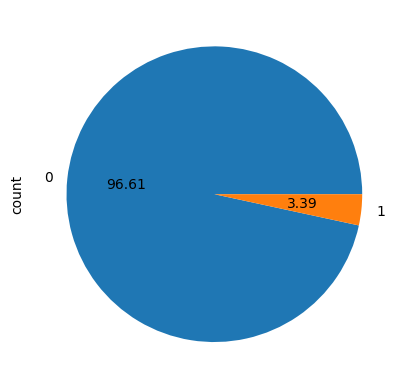

In [ ]:
df['Machine_failure'].value_counts().plot(kind='pie',autopct='%.2f')

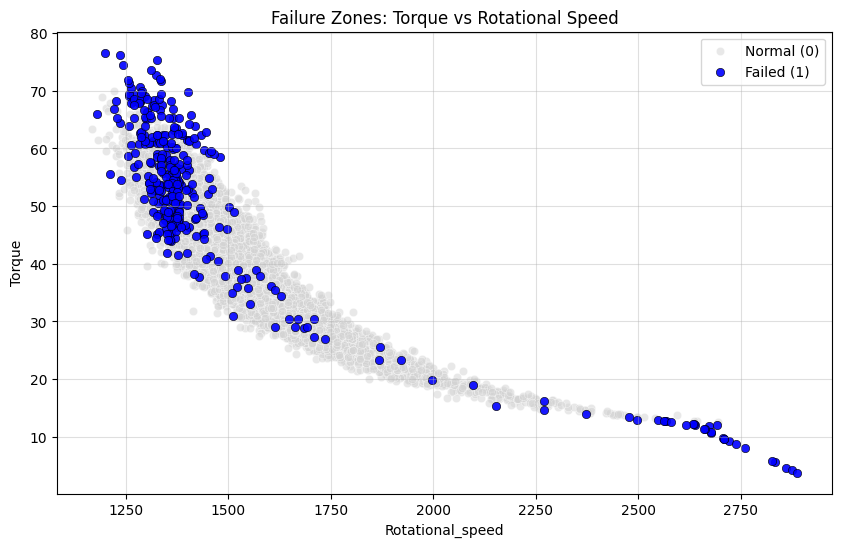

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df[df['Machine_failure'] == 0],
                x='Rotational_speed', y='Torque',
                color='lightgray', alpha=0.5, label='Normal (0)')

sns.scatterplot(data=df[df['Machine_failure'] == 1],
                x='Rotational_speed', y='Torque',
                color='blue', edgecolor='black', label='Failed (1)', alpha=0.9)

plt.title("Failure Zones: Torque vs Rotational Speed")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

**This chart explains that higher rotational speeds significantly lower the machine's torque tolerance.To prevent failure, predictive maintenance algorithms must ensure torque is kept strictly below this downward-sloping frontier as rotational speed increases.**

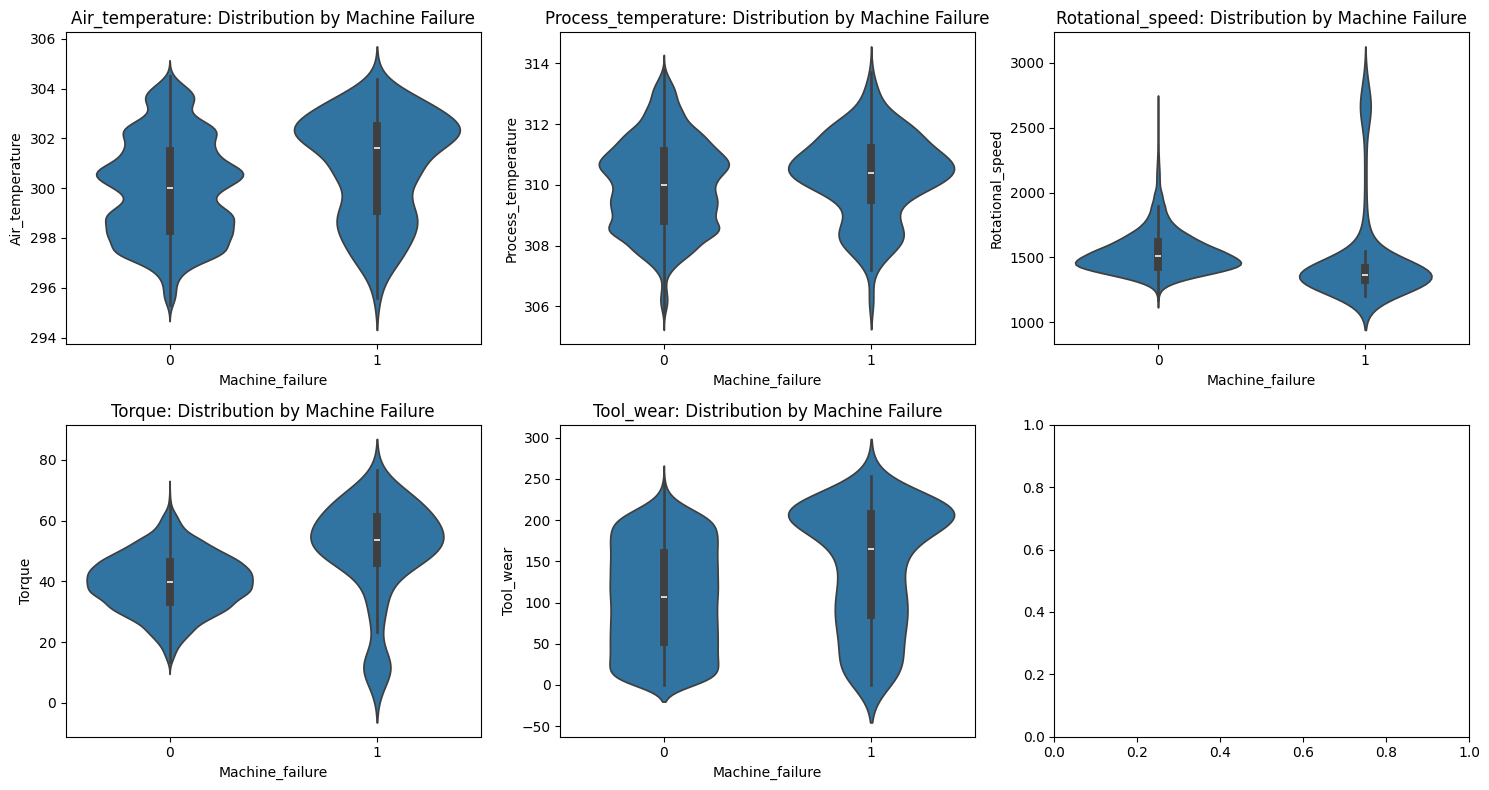

In [ ]:
features = ['Air_temperature', 'Process_temperature',
            'Rotational_speed', 'Torque', 'Tool_wear']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.violinplot(data=df, x='Machine_failure', y=feature, ax=axes[i])
    axes[i].set_title(f'{feature}: Distribution by Machine Failure')

plt.tight_layout()
plt.show()

4. Feature Selection and Feature Engineering

In [ ]:
cols = ['UDI','Product ID','Type','TWF', 'HDF', 'PWF', 'OSF','RNF']
df.drop(columns=cols,inplace=True,axis=1)

In [ ]:
df.head()

,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Machine_failure
0,298.1,308.6,1551,42.8,0,0
1,298.2,308.7,1408,46.3,3,0
2,298.1,308.5,1498,49.4,5,0
3,298.2,308.6,1433,39.5,7,0
4,298.2,308.7,1408,40.0,9,0


In [ ]:
df.describe()

,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Machine_failure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


**Feature Engineering :**

🌡️ **Temp_change :** Difference between process temperature and air temperature

⚙️ **Overstrain Index :** Product of tool wear and torque

🔥 **Thermal Efficiency :** Temp_change divided by rotational speed

These engineered features capture relationships related to thermal conditions, mechanical stress, and machine operating conditions.



In [ ]:
df['Temp_change'] = df['Process_temperature'] - df['Air_temperature']

df['Overstrain_index'] = df['Tool_wear'] * df['Torque']

df['Thermal_Efficiency'] = df['Temp_change']/df['Rotational_speed']

Checking Features Correlations

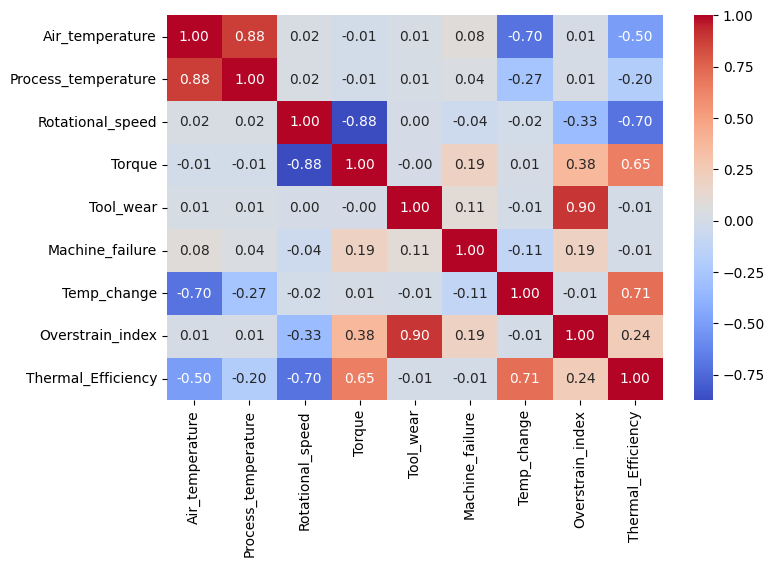

In [ ]:
plt.figure(figsize=(8,5))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f")
plt.show()

In [ ]:
df.drop(['Process_temperature','Air_temperature'],axis=1,inplace=True)

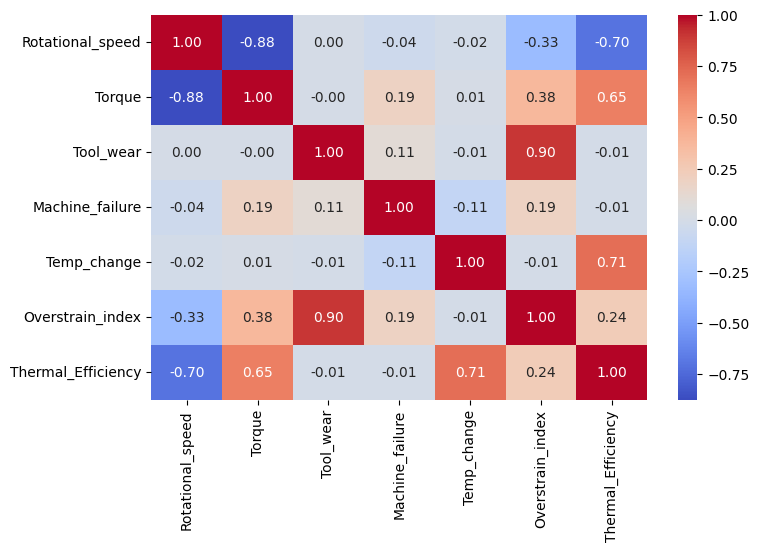

In [ ]:
plt.figure(figsize=(8,5))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f")
plt.show()

More EDA

/tmp/ipykernel_877/2580912300.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Temp_change'])
/tmp/ipykernel_877/2580912300.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Tool_wear'])
/tmp/ipykernel_877/2580912300.py:9: UserWarning: 

`distplot` is a deprecated function and will 

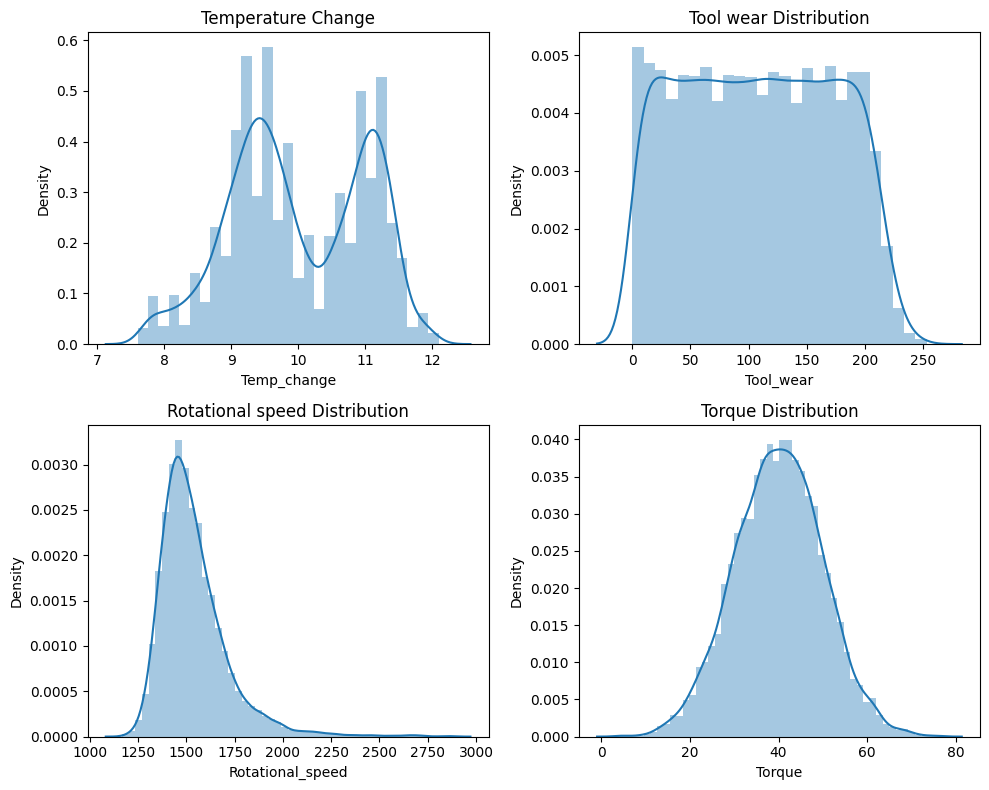

In [ ]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.distplot(df['Temp_change'])
plt.title('Temperature Change')
plt.subplot(2,2,2)
sns.distplot(df['Tool_wear'])
plt.title('Tool wear Distribution')
plt.subplot(2,2,3)
sns.distplot(df['Rotational_speed'])
plt.title('Rotational speed Distribution')
plt.subplot(2,2,4)
sns.distplot(df['Torque'])
plt.title('Torque Distribution')
plt.tight_layout()
plt.show()

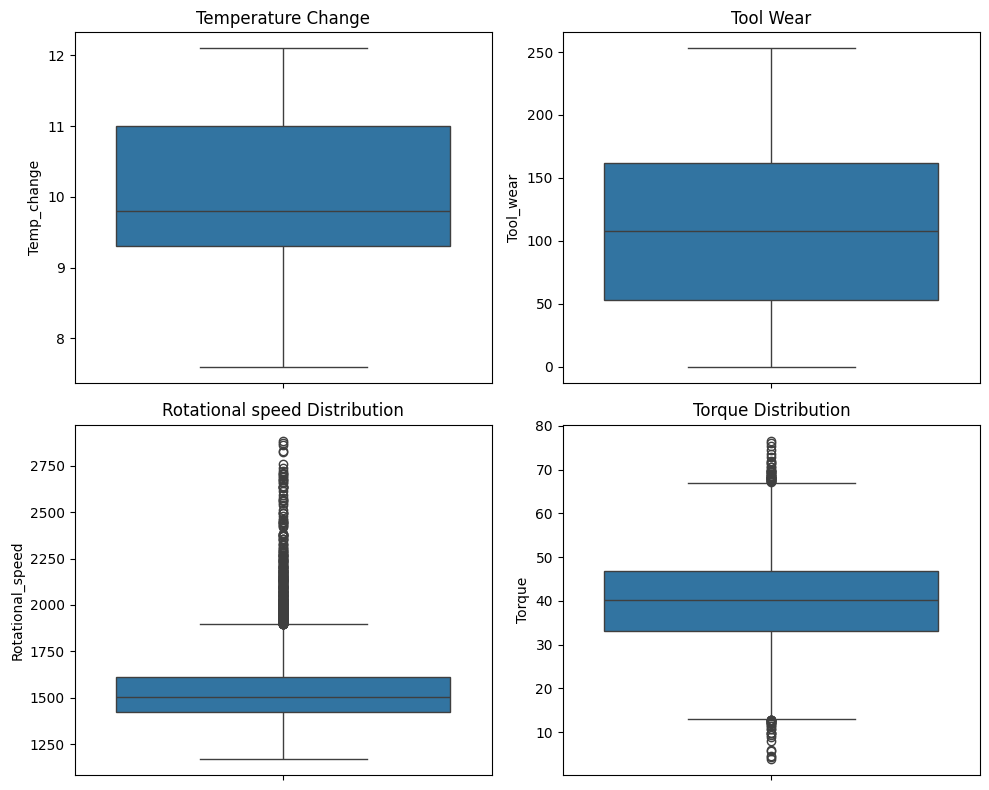

In [ ]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.boxplot(df['Temp_change'])
plt.title('Temperature Change')
plt.subplot(2,2,2)
sns.boxplot(df['Tool_wear'])
plt.title('Tool Wear')
plt.subplot(2,2,3)
sns.boxplot(df['Rotational_speed'])
plt.title('Rotational speed Distribution')
plt.subplot(2,2,4)
sns.boxplot(df['Torque'])
plt.title('Torque Distribution')
plt.tight_layout()
plt.show()

In [ ]:
for name in df.columns :
  if name != 'Machine_failure' :
    print(f"{name} : {df[name].skew()}")

Rotational_speed : 1.9931710047137523
Torque : -0.00951659584005855
Tool_wear : 0.027292239050452527
Temp_change : -0.07248395099894356
Overstrain_index : 0.4695471304643356
Thermal_Efficiency : -0.15881775735358847


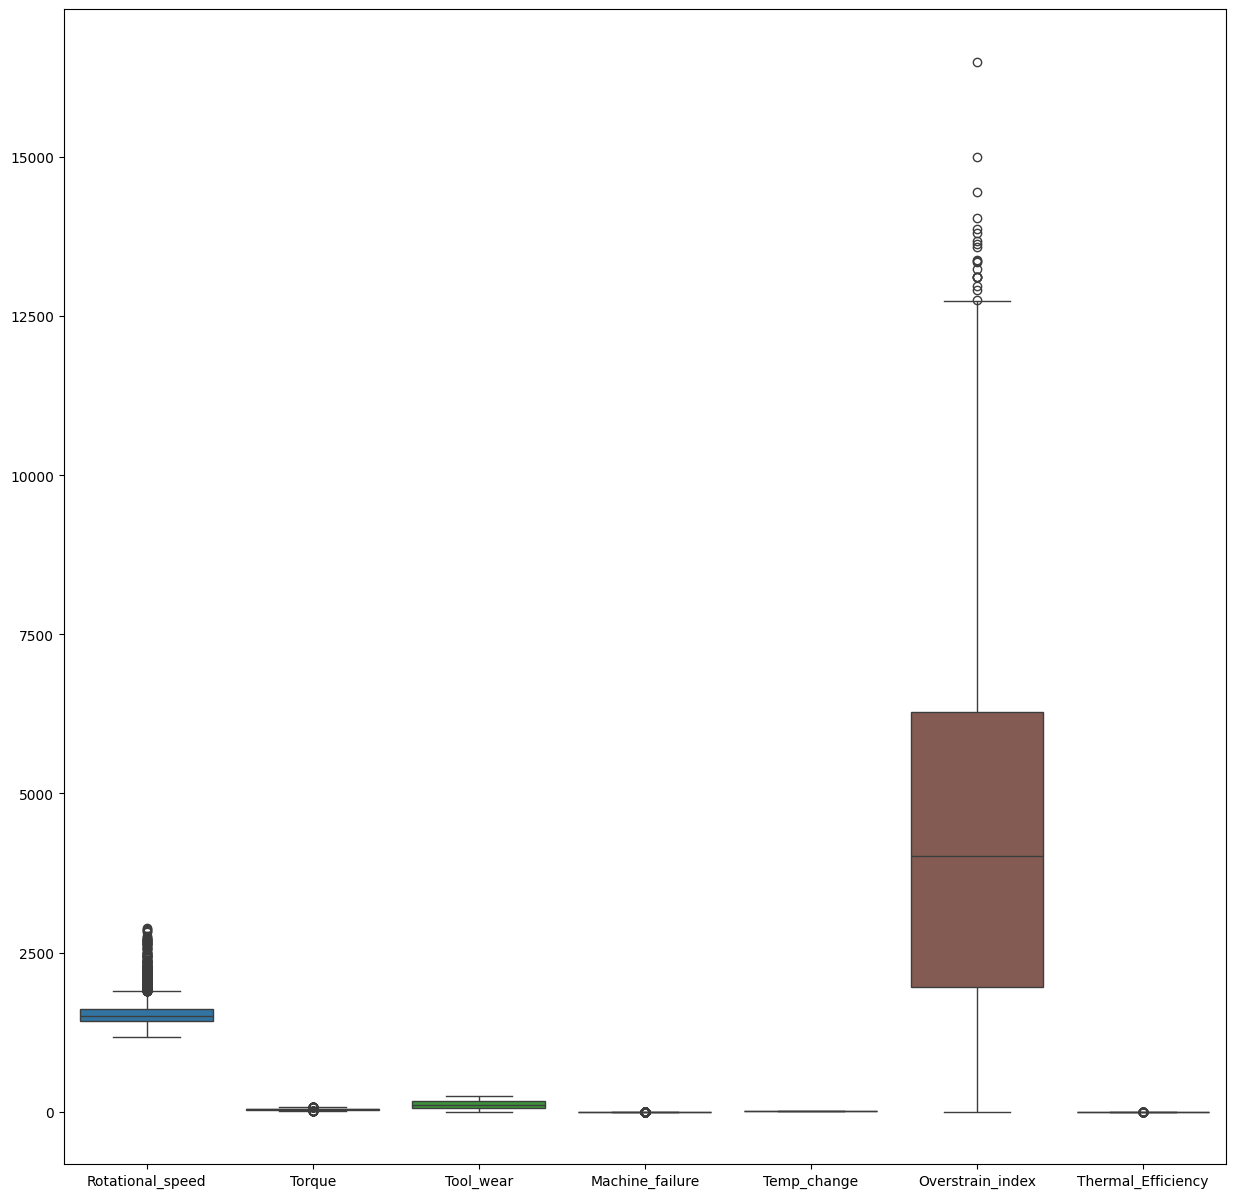

In [ ]:
fig,ax = plt.subplots(figsize=(15,15))
sns.boxplot(data=df)
plt.show()

Applying Log transformation on Rotational_speed feature due to high skewness and outliers reduction

In [ ]:
df['Rotational_speed'] = np.log1p(df['Rotational_speed'])
print(f"Rotational_speed skewness : {df['Rotational_speed'].skew()}")

Rotational_speed skewness : 1.3097082526694797


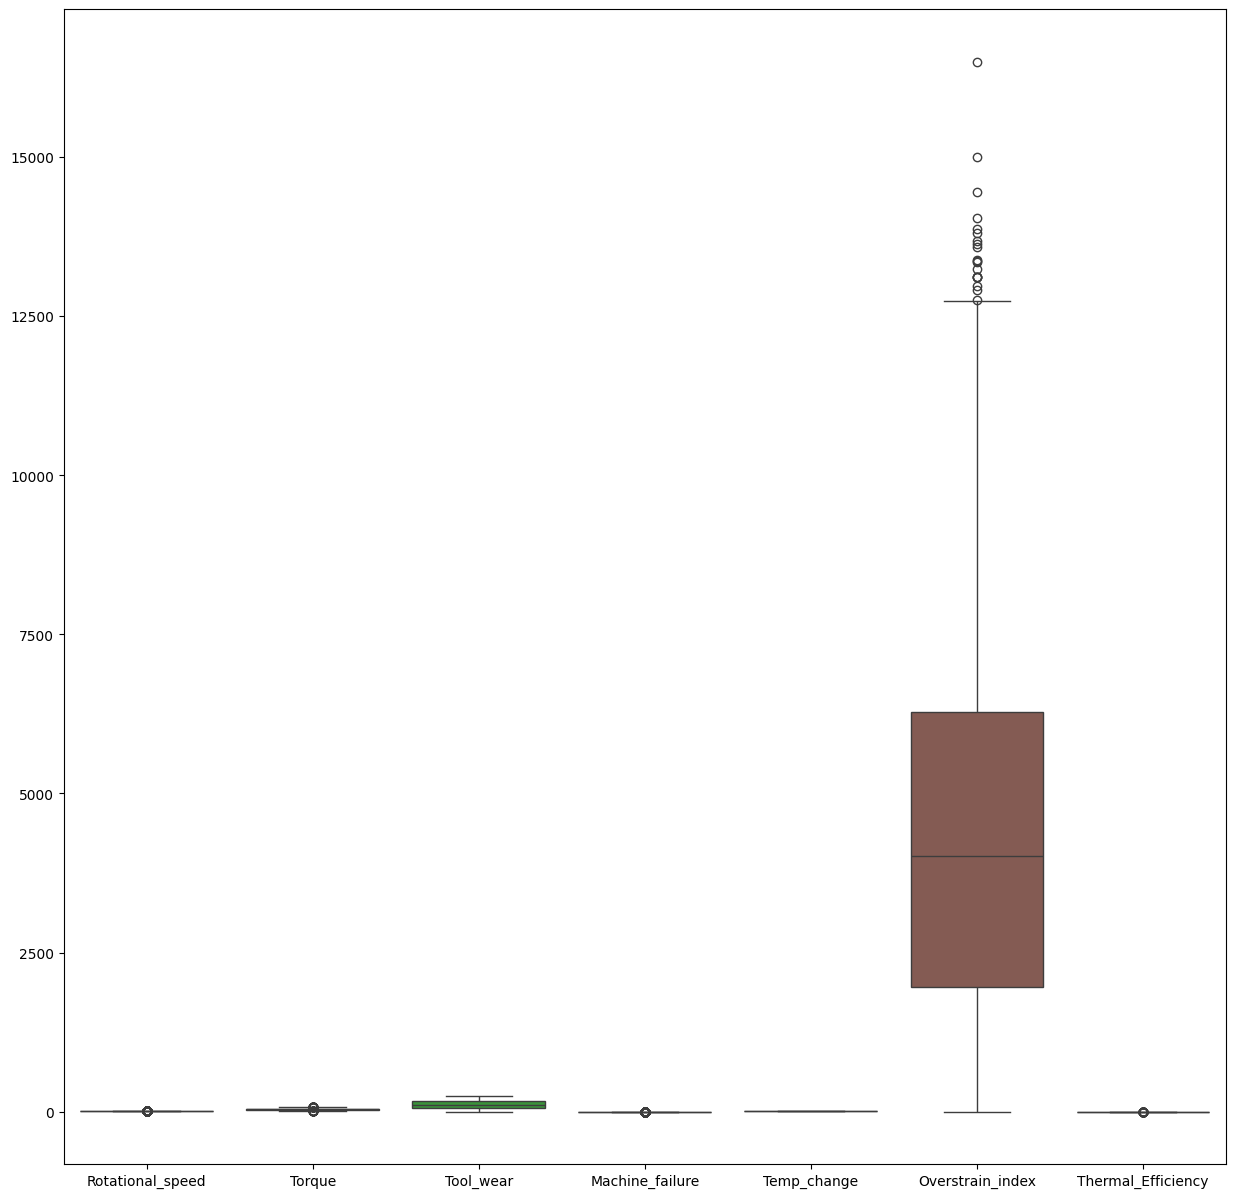

In [ ]:
fig,ax = plt.subplots(figsize=(15,15))
sns.boxplot(data=df)
plt.show()

In [ ]:
df.describe()

,Rotational_speed,Torque,Tool_wear,Machine_failure,Temp_change,Overstrain_index,Thermal_Efficiency
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,7.333330,39.986910,107.951000,0.033900,10.000630,4314.664550,0.006576
std,0.107449,9.968934,63.654147,0.180981,1.001094,2826.567692,0.000941
min,7.063904,3.800000,0.000000,0.000000,7.600000,0.000000,0.002840
25%,7.261225,33.200000,53.000000,0.000000,9.300000,1963.650000,0.005946
50%,7.315884,40.100000,108.000000,0.000000,9.800000,4012.950000,0.006574
75%,7.385851,46.800000,162.000000,0.000000,11.000000,6279.000000,0.007253
max,7.967973,76.600000,253.000000,1.000000,12.100000,16497.000000,0.009462


5. Splitting the dataset into training and testing

In [ ]:
X = df.drop('Machine_failure',axis=1)
Y = df['Machine_failure']

In [ ]:
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.1,random_state=42)

In [ ]:
Y.value_counts()

,count
Machine_failure,
0,9661
1,339


In [ ]:
Y_train.value_counts()

,count
Machine_failure,
0,8692
1,308


In [ ]:
Y_test.value_counts()

,count
Machine_failure,
0,969
1,31


In [ ]:
X_train

,Rotational_speed,Torque,Tool_wear,Temp_change,Overstrain_index,Thermal_Efficiency
4896,7.404279,32.3,206,8.7,6653.8,0.005298
4782,7.221836,52.6,123,8.7,6469.8,0.006360
1496,7.145984,69.4,189,10.7,13116.6,0.008438
1957,7.389564,35.9,92,9.8,3302.8,0.006057
9171,7.236339,45.6,190,11.1,8664.0,0.007997
...,...,...,...,...,...,...
5734,7.222566,56.2,208,9.5,11689.6,0.006939
5191,7.256297,46.0,128,9.2,5888.0,0.006497
5390,7.302496,47.2,223,9.5,10525.6,0.006406
860,7.340836,32.6,33,10.8,1075.8,0.007008


In [ ]:
X_test

,Rotational_speed,Torque,Tool_wear,Temp_change,Overstrain_index,Thermal_Efficiency
6252,7.338888,36.1,198,9.5,7147.8,0.006177
4684,7.259820,44.8,101,8.2,4524.8,0.005771
1731,7.303843,42.0,117,9.6,4914.0,0.006465
4742,7.373374,33.7,14,8.0,471.8,0.005025
4521,7.531552,23.9,129,8.0,3083.1,0.004290
...,...,...,...,...,...,...
3921,7.309881,41.4,149,8.8,6168.6,0.005890
6685,7.334982,43.6,15,9.3,654.0,0.006070
3194,7.282761,51.7,2,9.0,103.4,0.006190
1941,7.262629,58.2,57,9.8,3317.4,0.006877


6. Normalizing the data using MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
X_train_tran = scaler.fit_transform(X_train)
X_test_tran = scaler.transform(X_test)

In [ ]:
X_train_tran = pd.DataFrame(
    X_train_tran,
    columns=X_train.columns,
    index=X_train.index
)
X_test_tran = pd.DataFrame(
    X_test_tran,
    columns=X_test.columns,
    index=X_test.index
)

In [ ]:
X_train_tran

,Rotational_speed,Torque,Tool_wear,Temp_change,Overstrain_index,Thermal_Efficiency
4896,0.376492,0.391484,0.814229,0.244444,0.403334,0.371263
4782,0.174690,0.670330,0.486166,0.244444,0.392180,0.531531
1496,0.090790,0.901099,0.747036,0.688889,0.795090,0.845479
1957,0.360216,0.440934,0.363636,0.488889,0.200206,0.485804
9171,0.190732,0.574176,0.750988,0.777778,0.525186,0.778823
...,...,...,...,...,...,...
5734,0.175498,0.719780,0.822134,0.422222,0.708589,0.619081
5191,0.212808,0.579670,0.505929,0.355556,0.356913,0.552301
5390,0.263910,0.596154,0.881423,0.422222,0.638031,0.538521
860,0.306317,0.395604,0.130435,0.711111,0.065212,0.629512


In [ ]:
X_test_tran

,Rotational_speed,Torque,Tool_wear,Temp_change,Overstrain_index,Thermal_Efficiency
6252,0.304163,0.443681,0.782609,0.422222,0.433279,0.503925
4684,0.216704,0.563187,0.399209,0.133333,0.274280,0.442570
1731,0.265399,0.524725,0.462451,0.444444,0.297872,0.547388
4742,0.342308,0.410714,0.055336,0.088889,0.028599,0.329990
4521,0.517271,0.276099,0.509881,0.088889,0.186889,0.218902
...,...,...,...,...,...,...
3921,0.272078,0.516484,0.588933,0.266667,0.373923,0.460639
6685,0.299842,0.546703,0.059289,0.377778,0.039644,0.487863
3194,0.242080,0.657967,0.007905,0.311111,0.006268,0.505884
1941,0.219811,0.747253,0.225296,0.488889,0.201091,0.609691


#**📖Version A : Using Class Weights to handle Imbalanced Data**

In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(class_weight='balanced',penalty='l2',random_state=42),
    'Decision Tree' : DecisionTreeClassifier(class_weight='balanced',max_depth=6,min_samples_leaf=6,max_features='sqrt',random_state=42),
    'NB' : ComplementNB(),
    'KNN' : KNeighborsClassifier(weights='distance',n_neighbors=15),
    'SVM' : SVC(class_weight='balanced',C=0.7,random_state=42),
    'RF' : RandomForestClassifier(n_estimators=150,class_weight='balanced_subsample',max_depth=8,min_samples_leaf=5,max_features='sqrt',random_state=42),
    'XGB' : XGBClassifier(n_estimators=150,scale_pos_weight=1.7,max_depth=5,learning_rate=0.06,colsample_bytree=0.6,subsample=0.75,reg_lambda=2.57,random_state=42),
    'LightGBM' : LGBMClassifier(n_estimators=150,random_state=42)
}

for name , model in models.items() :
  model.fit(X_train_tran,Y_train)
  print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
NB trained successfully.
KNN trained successfully.
SVM trained successfully.
RF trained successfully.
XGB trained successfully.
[LightGBM] [Info] Number of positive: 308, number of negative: 8692
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000636 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1342
[LightGBM] [Info] Number of data points in the train set: 9000, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034222 -> initscore=-3.340059
[LightGBM] [Info] Start training from score -3.340059
LightGBM trained successfully.


#Models Prediction : Version A

In [ ]:
for name,model in models.items() :
  Y_pred = model.predict(X_test_tran)
  print(f"{name} metrics : \n")
  print(f"Training score = {model.score(X_train_tran,Y_train)}")
  print(f"Testing score = {model.score(X_test_tran,Y_test)}")
  print("Classification Report : ")
  print(classification_report(Y_test,Y_pred))
  print("\n")
  print(confusion_matrix(Y_test,Y_pred))
  if name != 'SVM' :
    prob = model.predict_proba(X_test_tran)[:,1]
    print(f"PR-AUC score : {average_precision_score(Y_test,prob)}")
    print(f"ROC score = {roc_auc_score(Y_test,prob)}")

Logistic Regression metrics : 

Training score = 0.8037777777777778
Testing score = 0.806
Classification Report : 
              precision    recall  f1-score   support

           0       0.99      0.80      0.89       969
           1       0.12      0.84      0.21        31

    accuracy                           0.81      1000
   macro avg       0.56      0.82      0.55      1000
weighted avg       0.97      0.81      0.87      1000



[[780 189]
 [  5  26]]
PR-AUC score : 0.2593724104528188
ROC score = 0.8745630680115849
Decision Tree metrics : 

Training score = 0.9641111111111111
Testing score = 0.959
Classification Report : 
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       969
           1       0.41      0.77      0.54        31

    accuracy                           0.96      1000
   macro avg       0.70      0.87      0.76      1000
weighted avg       0.97      0.96      0.96      1000



[[935  34]
 [  7  24]]
PR-AUC 

#Final Feature Importance of the best performing models in Version A

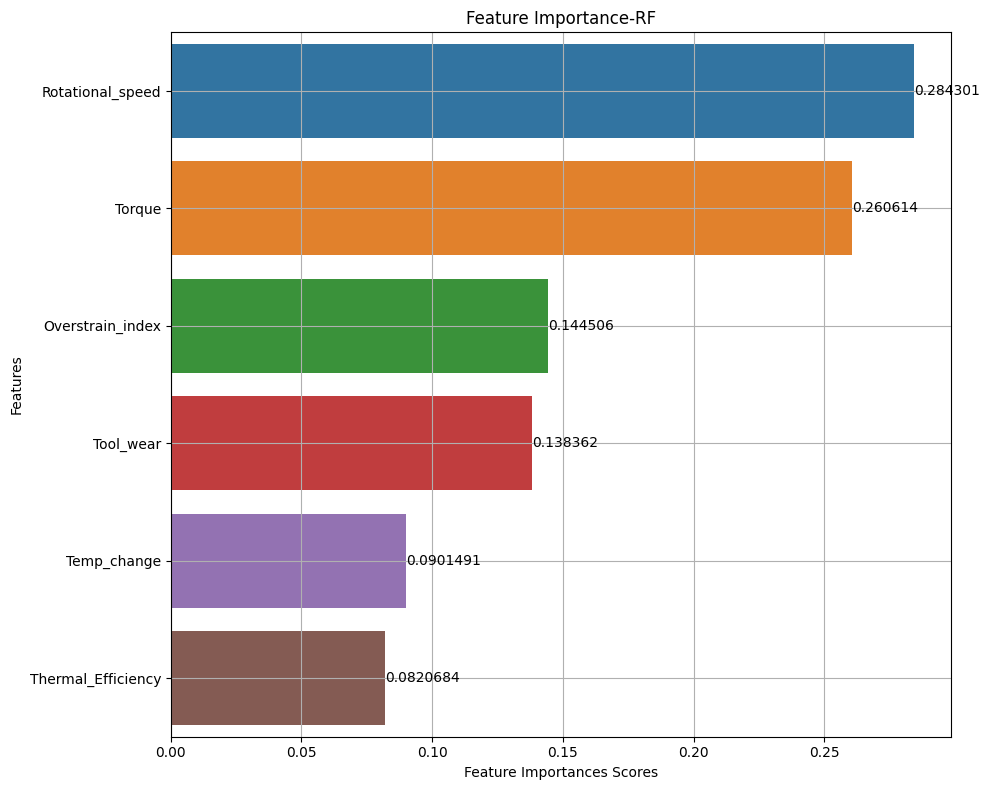

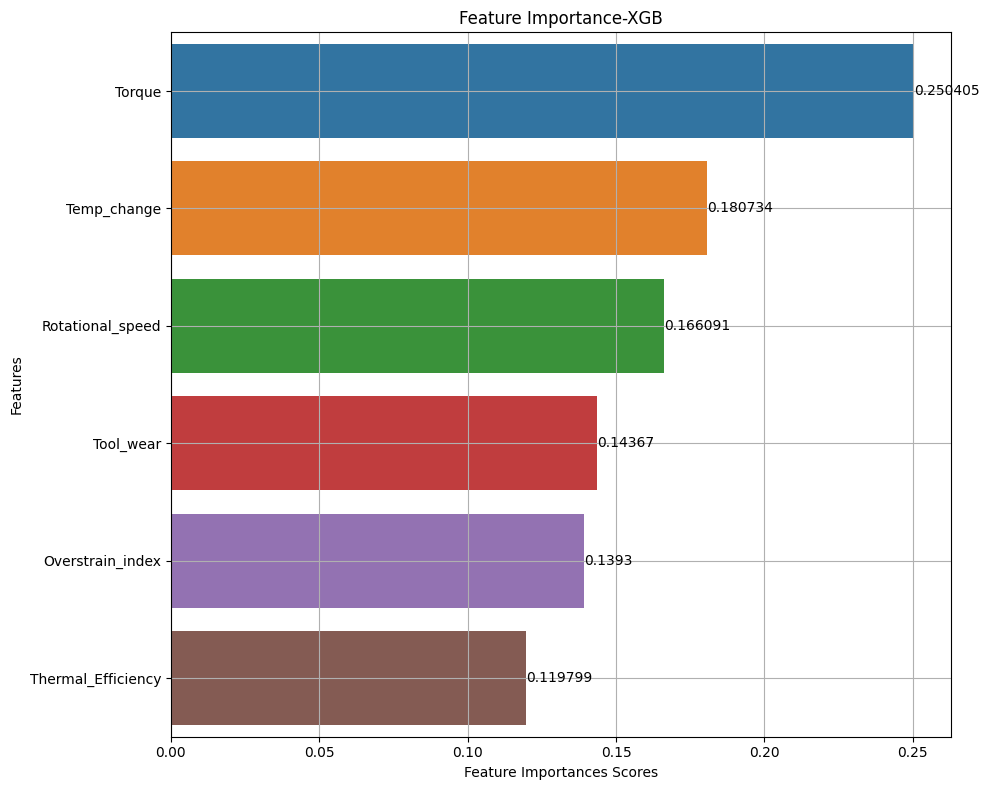

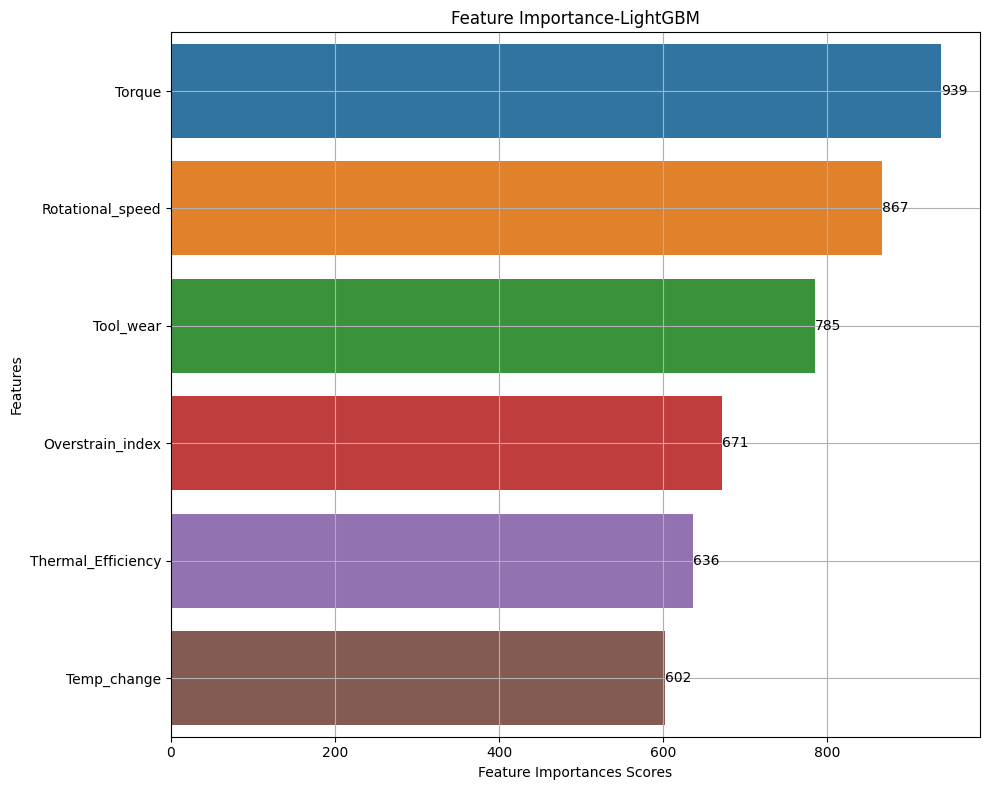

In [ ]:
for m_name,Models in models.items() :
  if m_name == 'RF' or m_name == 'XGB' or m_name == 'LightGBM':
    feature_importances = models[m_name].feature_importances_
    feature_names = X_train_tran.columns
    importance_df = pd.DataFrame({
      'feature' : feature_names,
      'importance' : feature_importances
    }).sort_values('importance',ascending=False)
    plt.figure(figsize=(10,8))
    plot = sns.barplot(data=importance_df,y='feature',x='importance',hue='feature')
    for i in plot.containers :
      plot.bar_label(i)
    plt.grid()
    plt.title(f"Feature Importance-{m_name}")
    plt.xlabel("Feature Importances Scores")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

# Hyperparameter Tuning best performing model : Version A

In [ ]:
param_grid = {
    'n_estimators' : [150,180,200,250,300,400,450,500,550,600,650,700],
    'max_depth' : [4,6,8,10,12],
    'min_samples_split' : [2,4,6,10],
    'min_samples_leaf' : [1,2,3,4],
    'max_features' : ['sqrt','log2',0.5],
    'max_samples' : [0.7,0.8,0.9,None],
    'criterion' : ['gini','entropy'],
    'class_weight' : ['balanced','balanced_subsample'],
    'bootstrap' : [True]
}

rf_search = RandomizedSearchCV(estimator=models['RF'],param_distributions=param_grid,cv=5,n_iter=75,scoring='f1',n_jobs=-1,random_state=42)
rf_search.fit(X_train_tran,Y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced_subsample',
                                                    max_depth=8,
                                                    min_samples_leaf=5,
                                                    n_estimators=150,
                                                    random_state=42),
                   n_iter=75, n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'class_weight': ['balanced',
                                                         'balanced_subsample'],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [4, 6, 8, 10, 12],
                                        'max_features': ['sqrt', 'log2', 0.5],
                                        'max_samples': [0.7, 0.8, 0.9, None],
                                        'min_samples_leaf': [1, 2, 3, 4],
                                        'min_samples_split': [2, 4, 6, 10],
                                        'n_estimators': [150, 180, 200, 250,
                                                         300, 400, 450, 500,
                                                         550, 600, 650, 700]},
                   random_state=42, scoring='f1')

In [ ]:
rf_search.best_params_

{'n_estimators': 300,
 'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_samples': 0.9,
 'max_features': 0.5,
 'max_depth': 12,
 'criterion': 'gini',
 'class_weight': 'balanced',
 'bootstrap': True}

Re-Training best model with the best parameters

In [ ]:
best_model = RandomForestClassifier(n_estimators=300,max_depth=10,min_samples_split=2,min_samples_leaf=4,
                                    max_features=0.5,max_samples=0.9,criterion='gini',class_weight='balanced',bootstrap=True,random_state=42)
best_model.fit(X_train_tran,Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, max_features=0.5,
                       max_samples=0.9, min_samples_leaf=4, n_estimators=300,
                       random_state=42)

Prediction

In [ ]:
def evaluate_model(best_model) :
  pred = best_model.predict(X_test_tran)
  print("Best Model metrics : \n")
  print(f"Training score = {best_model.score(X_train_tran,Y_train)}")
  print(f"Testing score = {best_model.score(X_test_tran,Y_test)}")
  print("Classification Report : ")
  print(classification_report(Y_test,pred))
  print("\n")
  print(confusion_matrix(Y_test,pred))
  probability = best_model.predict_proba(X_test_tran)[:,1]
  print(f"PR-AUC score : {average_precision_score(Y_test,probability)}")
  print(f"ROC score = {roc_auc_score(Y_test,probability)}")

evaluate_model(best_model)

Best Model metrics : 

Training score = 0.9931111111111111
Testing score = 0.988
Classification Report : 
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       969
           1       0.79      0.84      0.81        31

    accuracy                           0.99      1000
   macro avg       0.89      0.92      0.90      1000
weighted avg       0.99      0.99      0.99      1000



[[962   7]
 [  5  26]]
PR-AUC score : 0.8340865226385289
ROC score = 0.9792602949498986


#Training an ANN(Artificial Neural Network)

In [ ]:
X_train_tran.shape

(9000, 6)

In [ ]:
ann = Sequential()
ann.add(Dense(64,input_dim=6,activation="relu",kernel_regularizer=L2()))
ann.add(BatchNormalization())
ann.add(Dense(32,activation="relu",kernel_regularizer=L2()))
ann.add(BatchNormalization())
ann.add(Dense(16,activation="relu",kernel_regularizer=L2()))
ann.add(BatchNormalization())
ann.add(Dense(1,activation='sigmoid'))

ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ANN = ann.fit(X_train_tran,Y_train,batch_size=200,epochs=20,validation_data=[X_test_tran,Y_test],callbacks=EarlyStopping(patience=3,restore_best_weights=True))

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7159 - loss: 1.3451 - val_accuracy: 0.9690 - val_loss: 1.1944
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9138 - loss: 1.0441 - val_accuracy: 0.9690 - val_loss: 0.9104
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9597 - loss: 0.8147 - val_accuracy: 0.9690 - val_loss: 0.6936
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9710 - loss: 0.6333 - val_accuracy: 0.9690 - val_loss: 0.5417
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9737 - loss: 0.5002 - val_accuracy: 0.9690 - val_loss: 0.4438
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9760 - loss: 0.4050 - val_accuracy: 0.9690 - val_loss: 0.3865
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9778 - loss: 0.3369 - val_accuracy: 0.9690 - val_loss: 0.3383
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9793 - loss: 0.2883 - val_accuracy: 0.9690 - val_loss

In [ ]:
ann.evaluate(X_test_tran,Y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9770 - loss: 0.1313


[0.13131912052631378, 0.9769999980926514]

In [ ]:
Y_pred = ann.predict(X_test_tran)
prediction = (Y_pred > 0.5).astype(int)
print(classification_report(Y_test,prediction,target_names=['Class 0','Class 1']))
print(confusion_matrix(Y_test,prediction))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

     Class 0       0.98      1.00      0.99       969
     Class 1       0.90      0.29      0.44        31

    accuracy                           0.98      1000
   macro avg       0.94      0.64      0.71      1000
weighted avg       0.98      0.98      0.97      1000

[[968   1]
 [ 22   9]]


#📖**Version B : Synthetic Over-Sampling using SMOTE**

In [ ]:
x_train = X_train_tran
y_train = Y_train
x_test = X_test_tran
y_test = Y_test

In [ ]:
smote = SMOTE(random_state=42)
x_train_res,y_train_res = smote.fit_resample(x_train,y_train)

In [ ]:
y_train_res.value_counts()

,count
Machine_failure,
0,8692
1,8692


#Training the models : Version B

In [ ]:
Models = {
    'Logistic Regression' : LogisticRegression(penalty='l2',random_state=42),
    'Decision Tree' : DecisionTreeClassifier(max_depth=6,min_samples_leaf=6,max_features='sqrt',random_state=42),
    'NB' : ComplementNB(),
    'KNN' : KNeighborsClassifier(weights='distance',n_neighbors=15),
    'SVM' : SVC(C=0.9,random_state=42),
    'RF' : RandomForestClassifier(n_estimators=200,max_depth=6,min_samples_leaf=4,random_state=42),
    'XGB' : XGBClassifier(n_estimators=200,max_depth=5,learning_rate=0.06,colsample_bytree=0.6,subsample=0.75,reg_lambda=2.57,random_state=42),
    'LightGBM' : LGBMClassifier(n_estimators=200,random_state=42)
}

for Name , Model in Models.items() :
  Model.fit(x_train_res,y_train_res)
  print(f"{Name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
NB trained successfully.
KNN trained successfully.
SVM trained successfully.
RF trained successfully.
XGB trained successfully.
[LightGBM] [Info] Number of positive: 8692, number of negative: 8692
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001005 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 17384, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM trained successfully.


#Models Prediction : Version B

In [ ]:
for Name,Model in Models.items() :
  y_pred = Model.predict(x_test)
  print(f"{Name} metrics : \n")
  print(f"Training score = {Model.score(x_train_res,y_train_res)}")
  print(f"Testing score = {Model.score(x_test,y_test)}")
  print("Classification Report : ")
  print(classification_report(y_test,y_pred))
  print("\n")
  print(confusion_matrix(y_test,y_pred))
  if Name != 'SVM' :
    probability = Model.predict_proba(x_test)[:,1]
    print(f"PR-AUC score : {average_precision_score(y_test,probability)}")
    print(f"ROC score = {roc_auc_score(y_test,probability)}")

Logistic Regression metrics : 

Training score = 0.8047054763000461
Testing score = 0.81
Classification Report : 
              precision    recall  f1-score   support

           0       0.99      0.81      0.89       969
           1       0.12      0.84      0.21        31

    accuracy                           0.81      1000
   macro avg       0.56      0.82      0.55      1000
weighted avg       0.97      0.81      0.87      1000



[[784 185]
 [  5  26]]
PR-AUC score : 0.2617533876225832
ROC score = 0.8729318552548354
Decision Tree metrics : 

Training score = 0.9309134836631385
Testing score = 0.929
Classification Report : 
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       969
           1       0.28      0.84      0.42        31

    accuracy                           0.93      1000
   macro avg       0.64      0.89      0.69      1000
weighted avg       0.97      0.93      0.95      1000



[[903  66]
 [  5  26]]
PR-AUC s

#Hyperparameter Tuning best performing model in Version B

In [ ]:
param_grid1 = {
    'n_estimators' : [150,200,250,300,400,500],
    'max_depth' : [4,6,8,10],
    'min_samples_split' : [4,6,10],
    'min_samples_leaf' : [2,4,6],
    'max_features' : ['sqrt','log2',0.5],
    'max_samples' : [0.7,0.8,0.9,None],
    'criterion' : ['gini','entropy'],
    'bootstrap' : [True]
}

rf_search1 = RandomizedSearchCV(estimator=Models['RF'],param_distributions=param_grid1,cv=5,n_iter=50,scoring='f1',n_jobs=1,random_state=42)
rf_search1.fit(x_train_res,y_train_res)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(max_depth=6,
                                                    min_samples_leaf=4,
                                                    n_estimators=200,
                                                    random_state=42),
                   n_iter=50, n_jobs=1,
                   param_distributions={'bootstrap': [True],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [4, 6, 8, 10],
                                        'max_features': ['sqrt', 'log2', 0.5],
                                        'max_samples': [0.7, 0.8, 0.9, None],
                                        'min_samples_leaf': [2, 4, 6],
                                        'min_samples_split': [4, 6, 10],
                                        'n_estimators': [150, 200, 250, 300,
                                                         400, 500]},
                   random_state=42, scoring='f1')

In [ ]:
rf_search1.best_params_

{'n_estimators': 300,
 'min_samples_split': 4,
 'min_samples_leaf': 2,
 'max_samples': 0.8,
 'max_features': 0.5,
 'max_depth': 10,
 'criterion': 'gini',
 'bootstrap': True}

Re-Training the best model with best parameteres : Version B

In [ ]:
Best_Model = RandomForestClassifier(n_estimators=300,max_depth=10,min_samples_leaf=2,min_samples_split=4,max_samples=0.8,max_features=0.5,
                                    criterion='gini',bootstrap=True,random_state=42)
Best_Model.fit(x_train_res,y_train_res)

RandomForestClassifier(max_depth=10, max_features=0.5, max_samples=0.8,
                       min_samples_leaf=2, min_samples_split=4,
                       n_estimators=300, random_state=42)

Prediction

In [ ]:
def evaluate1(Best_Model) :
  prediction = Best_Model.predict(x_test)
  p = model.predict_proba(x_test)[:,1]
  pr = (p >= 0.3).astype(int)
  print("Best Model metrics : \n")
  print(f"Training score = {Best_Model.score(x_train_res,y_train_res)}")
  print(f"Testing score = {Best_Model.score(x_test,y_test)}")
  print("Classification Report : ")
  print(classification_report(y_test,pr))
  print("\n")
  print(confusion_matrix(y_test,pr))
  print(f"PR-AUC score : {average_precision_score(y_test,pr)}")
  print(f"ROC score = {roc_auc_score(y_test,pr)}")

evaluate1(Best_Model)

Best Model metrics : 

Training score = 0.9824551311550851
Testing score = 0.963
Classification Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       969
           1       0.85      0.74      0.79        31

    accuracy                           0.99      1000
   macro avg       0.92      0.87      0.89      1000
weighted avg       0.99      0.99      0.99      1000



[[965   4]
 [  8  23]]
PR-AUC score : 0.6400191158900836
ROC score = 0.8689037584473518


#Training an ANN(Artificial Neural Network) : Version B

In [ ]:
x_train_res.shape

(17384, 6)

In [ ]:
ann = Sequential()
ann.add(Dense(64,input_dim=6,activation="tanh",kernel_regularizer=L2()))
ann.add(BatchNormalization())
ann.add(Dense(32,activation="tanh",kernel_regularizer=L2()))
ann.add(BatchNormalization())
ann.add(Dense(16,activation="tanh",kernel_regularizer=L2()))
ann.add(BatchNormalization())
ann.add(Dense(1,activation='sigmoid'))

ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ANN = ann.fit(x_train_res,y_train_res,batch_size=200,epochs=20,validation_data=[x_test,y_test],callbacks=EarlyStopping(patience=3,restore_best_weights=True))

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8577 - loss: 0.9646 - val_accuracy: 0.9690 - val_loss: 0.6915
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9119 - loss: 0.6829 - val_accuracy: 0.9690 - val_loss: 0.5463
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9199 - loss: 0.5683 - val_accuracy: 0.9690 - val_loss: 0.5047
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9276 - loss: 0.4917 - val_accuracy: 0.9690 - val_loss: 0.4602
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9271 - loss: 0.4504 - val_accuracy: 0.9690 - val_loss: 0.3905
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9283 - loss: 0.4119 - val_accuracy: 0.9690 - val_loss: 0.3119
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9339 - loss: 0.3791 - val_accuracy: 0.9750 - val_loss: 0.2744
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9329 - loss: 0.3556 - val_accuracy: 0.9740 - val_loss:

In [ ]:
ann.evaluate(x_test,y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9690 - loss: 0.2365


[0.23653550446033478, 0.968999981880188]

In [ ]:
y_prediction = ann.predict(x_test)
prediction = (y_prediction > 0.5).astype(int)
print(classification_report(y_test,prediction,target_names=['Class 0','Class 1']))
print(confusion_matrix(y_test,prediction))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

     Class 0       0.98      0.99      0.98       969
     Class 1       0.50      0.42      0.46        31

    accuracy                           0.97      1000
   macro avg       0.74      0.70      0.72      1000
weighted avg       0.97      0.97      0.97      1000

[[956  13]
 [ 18  13]]


#**📌Final Best Model : Random Forest (Version-A)**

  **Accuracy ~ 98%**

  **Precision ~ 79%**

  **Recall ~ 84%**

  **F1-Score ~ 81%**

  **PR-AUC ~ 83%**
  
  **ROC ~ 98%**

#✅**Confusion Matrix of the best model : Random-Forest(Version-A)**

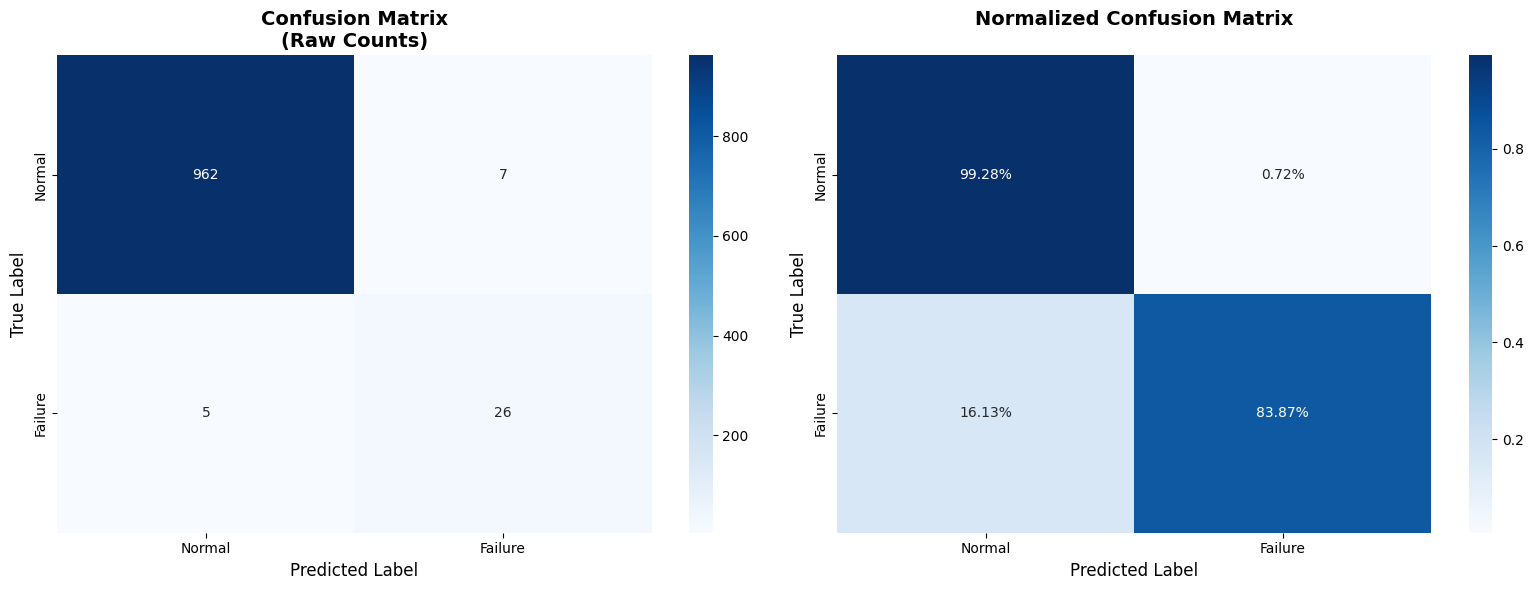

In [ ]:
ypred = best_model.predict(X_test_tran)

class_names = ['Normal','Failure']
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,6))

cm1 = confusion_matrix(Y_test,ypred)
sns.heatmap(cm1,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names,ax=ax1)
ax1.set_title("Confusion Matrix\n(Raw Counts)",fontsize=14,fontweight='bold')
ax1.set_ylabel("True Label",fontsize=12)
ax1.set_xlabel("Predicted Label",fontsize=12)

cm2 = confusion_matrix(Y_test,ypred,normalize='true')
sns.heatmap(cm2,annot=True,fmt='.2%',cmap='Blues',xticklabels=class_names,yticklabels=class_names,ax=ax2)
ax2.set_title("Normalized Confusion Matrix\n",fontsize=14,fontweight='bold')
ax2.set_ylabel("True Label",fontsize=12)
ax2.set_xlabel("Predicted Label",fontsize=12)

plt.tight_layout()
plt.show()

#📊**ROC-AUC Curve for the best model**

The ROC Curve measures how well the model separates the positive class from the negative class across all possible classification thresholds.

**X-Axis (False Positive Rate):** The proportion of actual negative cases that were incorrectly flagged as positive.

**Y-Axis (True Positive Rate / Recall):** The proportion of actual positive cases that the model correctly caught.

**The Takeaway:** The curve climbs rapidly toward the top-left corner, and the AUC of 0.979 indicates near-perfect separation. However, this high score is heavily inflated because the dataset contains a massive number of true negative examples.

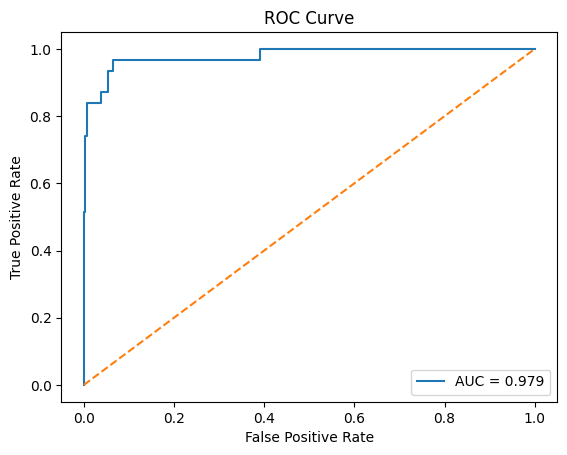

In [ ]:
y_probs = best_model.predict_proba(X_test_tran)[:, 1]

fpr, tpr, threshold = roc_curve(Y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


#**📊PR-Curve plot for the best model**

The Precision-Recall Curve measures a model's effectiveness at identifying positive cases without creating too many false alarms. It is the best evaluation tool when the target class is rare or heavily imbalanced.

**X-Axis (Recall / Sensitivity):** The proportion of all actual positive cases that the model correctly caught.

**Y-Axis (Precision):** The proportion of predicted positive cases that were actually correct.

**The Takeaway:** The model maintains high precision initially but drops as it tries to catch every single positive case. The overall PR AUC of 0.834 indicates strong performance despite a noticeable rate of false alarms.

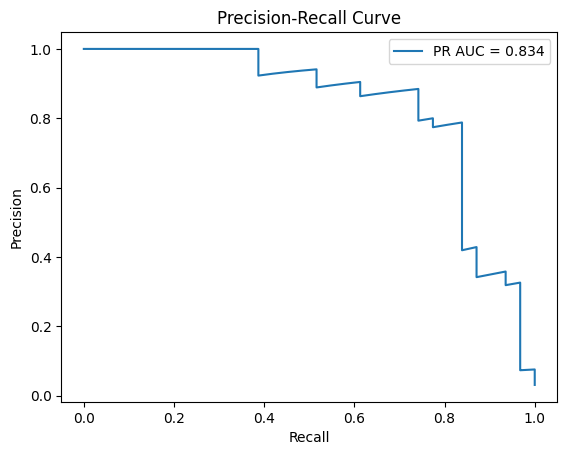

In [ ]:
precision, recall, threshold = precision_recall_curve(Y_test, y_probs)
pr_auc = average_precision_score(Y_test, y_probs)

plt.figure()
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


#🚀**Conclusion**

**This project demonstrates the application of machine learning for predictive maintenance. By predicting potential machine failures from operational data, the system can help reduce unexpected downtime, improve maintenance planning, and increase machine reliability.**